In [2]:
pip install pandas spacy nltk matplotlib wordcloud

In [5]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import pandas as pd
import spacy
import nltk
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from nltk.util import ngrams
from collections import Counter

In [2]:
# load NLP Model
nlp = spacy.load("en_core_web_sm")

In [3]:
#create movie dataset
data = {
    "movie": [
        "Inception",
        "Titanic",
        "The Dark Knight",
        "Avengers Endgame",
        "Jurassic Park"
    ],

    "plot": [
        "Dom Cobb is a skilled thief who enters the dreams of people to steal secrets. He is hired by a businessman in Los Angeles to perform an unusual mission.",

        "Jack meets Rose on the Titanic during its journey from Southampton to New York. Their relationship develops while the ship faces a tragic disaster.",

        "Batman protects Gotham City from the Joker, a dangerous criminal who wants to create chaos throughout the city.",

        "The Avengers return to fight Thanos after he destroys half of the living beings in the universe. The heroes travel through time to save the world.",

        "Dr Alan Grant visits Jurassic Park on an island near Costa Rica. The park contains genetically engineered dinosaurs that escape and threaten the visitors."
    ]
}

df = pd.DataFrame(data)

print(df)

              movie                                               plot
0         Inception  Dom Cobb is a skilled thief who enters the dre...
1           Titanic  Jack meets Rose on the Titanic during its jour...
2   The Dark Knight  Batman protects Gotham City from the Joker, a ...
3  Avengers Endgame  The Avengers return to fight Thanos after he d...
4     Jurassic Park  Dr Alan Grant visits Jurassic Park on an islan...


In [4]:
#Combine Movie Plots
text = " ".join(df["plot"])

print(text)

Dom Cobb is a skilled thief who enters the dreams of people to steal secrets. He is hired by a businessman in Los Angeles to perform an unusual mission. Jack meets Rose on the Titanic during its journey from Southampton to New York. Their relationship develops while the ship faces a tragic disaster. Batman protects Gotham City from the Joker, a dangerous criminal who wants to create chaos throughout the city. The Avengers return to fight Thanos after he destroys half of the living beings in the universe. The heroes travel through time to save the world. Dr Alan Grant visits Jurassic Park on an island near Costa Rica. The park contains genetically engineered dinosaurs that escape and threaten the visitors.


In [5]:
#NLP processing
doc = nlp(text)

In [6]:
#remove stop words
words = [
    token.text.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and token.is_alpha
]

print(words)

['dom', 'cobb', 'skilled', 'thief', 'enters', 'dreams', 'people', 'steal', 'secrets', 'hired', 'businessman', 'los', 'angeles', 'perform', 'unusual', 'mission', 'jack', 'meets', 'rose', 'titanic', 'journey', 'southampton', 'new', 'york', 'relationship', 'develops', 'ship', 'faces', 'tragic', 'disaster', 'batman', 'protects', 'gotham', 'city', 'joker', 'dangerous', 'criminal', 'wants', 'create', 'chaos', 'city', 'avengers', 'return', 'fight', 'thanos', 'destroys', 'half', 'living', 'beings', 'universe', 'heroes', 'travel', 'time', 'save', 'world', 'dr', 'alan', 'grant', 'visits', 'jurassic', 'park', 'island', 'near', 'costa', 'rica', 'park', 'contains', 'genetically', 'engineered', 'dinosaurs', 'escape', 'threaten', 'visitors']


In [7]:
#Word frequency
word_frequency = Counter(words)

print("Most Frequent Words:")

for word, count in word_frequency.most_common(10):
    print(word, ":", count)

Most Frequent Words:
city : 2
park : 2
dom : 1
cobb : 1
skilled : 1
thief : 1
enters : 1
dreams : 1
people : 1
steal : 1


In [8]:
##named entity extraction
print("\nNamed Entities:")

for entity in doc.ents:
    print(entity.text, "->", entity.label_)


Named Entities:
Dom Cobb -> PERSON
Los Angeles -> GPE
Jack -> PERSON
Rose -> PERSON
Titanic -> ORG
Southampton -> GPE
New York -> GPE
Gotham City -> GPE
Joker -> PERSON
Avengers -> PERSON
Thanos -> PRODUCT
half -> CARDINAL
Alan Grant -> PERSON
Jurassic Park -> FAC
Costa Rica -> GPE


In [9]:
entity_types = Counter()

for entity in doc.ents:
    entity_types[entity.label_] += 1

print("\nEntity Type Frequency:")

for entity, count in entity_types.items():
    print(entity, ":", count)


Entity Type Frequency:
PERSON : 6
GPE : 5
ORG : 1
PRODUCT : 1
CARDINAL : 1
FAC : 1


In [10]:
#Key phrased extraction
print("\nKey Phrases:")

key_phrases = []

for chunk in doc.noun_chunks:
    phrase = chunk.text.lower().strip()

    if len(phrase.split()) > 1:
        key_phrases.append(phrase)

for phrase in key_phrases:
    print(phrase)


Key Phrases:
dom cobb
a skilled thief
the dreams
a businessman
los angeles
an unusual mission
the titanic
its journey
new york
their relationship
the ship
a tragic disaster
gotham city
the joker
a dangerous criminal
the city
the avengers
the living beings
the universe
the heroes
the world
dr alan grant
jurassic park
an island
costa rica
the park
genetically engineered dinosaurs
the visitors


In [11]:
phrase_frequency = Counter(key_phrases)

print("\nMost Common Key Phrases:")

for phrase, count in phrase_frequency.most_common(10):
    print(phrase, ":", count)


Most Common Key Phrases:
dom cobb : 1
a skilled thief : 1
the dreams : 1
a businessman : 1
los angeles : 1
an unusual mission : 1
the titanic : 1
its journey : 1
new york : 1
their relationship : 1


In [12]:
#Unigram extraction
unigrams = list(ngrams(words, 1))

unigram_frequency = Counter(unigrams)

print("\nTop Unigrams:")

for gram, count in unigram_frequency.most_common(10):
    print(gram[0], ":", count)


Top Unigrams:
city : 2
park : 2
dom : 1
cobb : 1
skilled : 1
thief : 1
enters : 1
dreams : 1
people : 1
steal : 1


In [13]:
#Bigram extraction
bigrams = list(ngrams(words, 2))

bigram_frequency = Counter(bigrams)

print("\nTop Bigrams:")

for gram, count in bigram_frequency.most_common(10):
    print(" ".join(gram), ":", count)


Top Bigrams:
dom cobb : 1
cobb skilled : 1
skilled thief : 1
thief enters : 1
enters dreams : 1
dreams people : 1
people steal : 1
steal secrets : 1
secrets hired : 1
hired businessman : 1


In [14]:
#Trigram Extraction
trigrams = list(ngrams(words, 3))

trigram_frequency = Counter(trigrams)

print("\nTop Trigrams:")

for gram, count in trigram_frequency.most_common(10):
    print(" ".join(gram), ":", count)


Top Trigrams:
dom cobb skilled : 1
cobb skilled thief : 1
skilled thief enters : 1
thief enters dreams : 1
enters dreams people : 1
dreams people steal : 1
people steal secrets : 1
steal secrets hired : 1
secrets hired businessman : 1
hired businessman los : 1


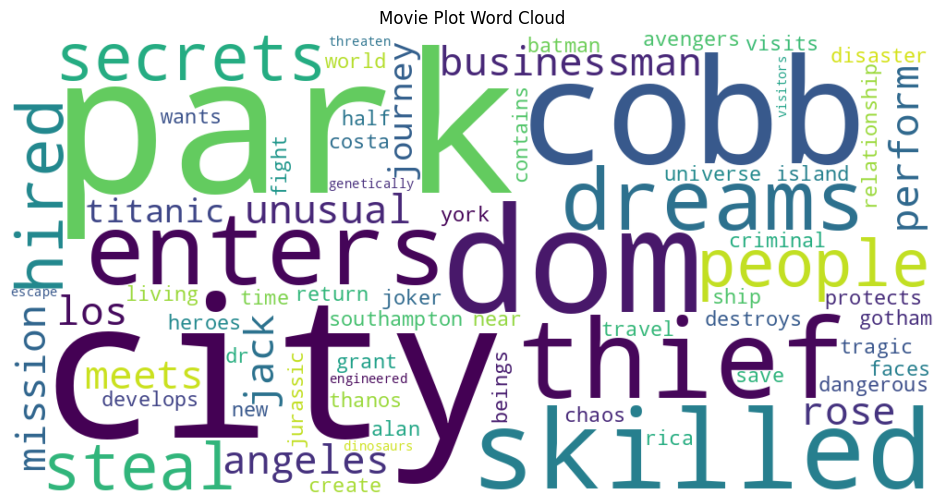

In [15]:
#Word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Movie Plot Word Cloud")
plt.show()

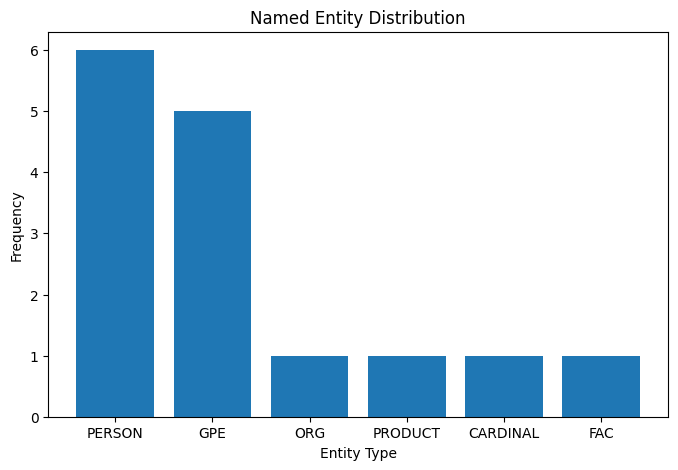

In [16]:
#Entity Visualization
labels = list(entity_types.keys())
values = list(entity_types.values())

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.title("Named Entity Distribution")

plt.show()

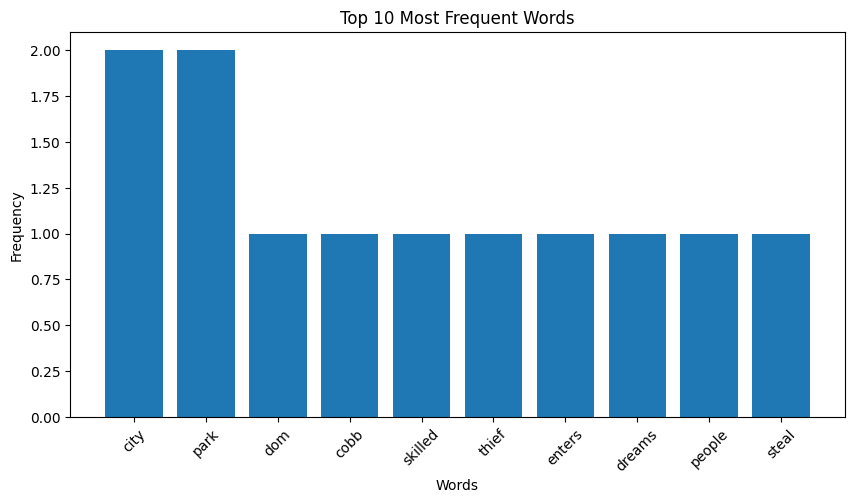

In [17]:
top_words = word_frequency.most_common(10)

words_list = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words_list, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words")

plt.xticks(rotation=45)

plt.show()

In [18]:
entity_data = []

for entity in doc.ents:
    entity_data.append({
        "Entity": entity.text,
        "Type": entity.label_
    })

entity_df = pd.DataFrame(entity_data)

print(entity_df)

           Entity      Type
0        Dom Cobb    PERSON
1     Los Angeles       GPE
2            Jack    PERSON
3            Rose    PERSON
4         Titanic       ORG
5     Southampton       GPE
6        New York       GPE
7     Gotham City       GPE
8           Joker    PERSON
9        Avengers    PERSON
10         Thanos   PRODUCT
11           half  CARDINAL
12     Alan Grant    PERSON
13  Jurassic Park       FAC
14     Costa Rica       GPE


In [19]:
entity_df.to_csv(
    "movie_entities.csv",
    index=False
)
print("\nEntity results saved to movie_entities.csv")


Entity results saved to movie_entities.csv
